<a href="https://colab.research.google.com/github/gogulasaimounika/Predictive-Analytics-lab/blob/customer-churn-prediction/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset (update the path to your CSV file)
df = pd.read_csv('customer churn prediction.csv')

# Quick peek at data
print(df.head())

# Drop customerID column if exists (not needed for modeling)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Convert TotalCharges to numeric, coerce errors (some might be spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode categorical variables
# Find all categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Churn')  # Leave target column aside for label encoding

# Convert categorical columns to numeric using LabelEncoder or get_dummies
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode target variable 'Churn' (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Define features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (optional but helpful)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  0001-XXXX    Male              0     Yes        Yes       5           No   
1  0002-XXXX  Female              0      No         No      42          Yes   
2  0003-XXXX    Male              0      No         No      61          Yes   
3  0004-XXXX    Male              1      No        Yes      22          Yes   
4  0005-XXXX    Male              1     Yes        Yes      21           No   

      MultipleLines InternetService       OnlineSecurity  ...  \
0               Yes              No                   No  ...   
1  No phone service             DSL                  Yes  ...   
2  No phone service              No                   No  ...   
3                No              No  No internet service  ...   
4                No             DSL                   No  ...   

      DeviceProtection TechSupport          StreamingTV      StreamingMovies  \
0                   No          No                   N

# Task
Generate two plots based on the provided code: one visualizing the data and another visualizing the model's performance.

## Visualize data

### Subtask:
Generate plots to visualize some aspects of the data, such as the distribution of churn or the relationship between features and churn.


**Reasoning**:
Create visualizations to explore the data, focusing on the distribution of churn and the relationship between features and churn, as requested in the instructions.



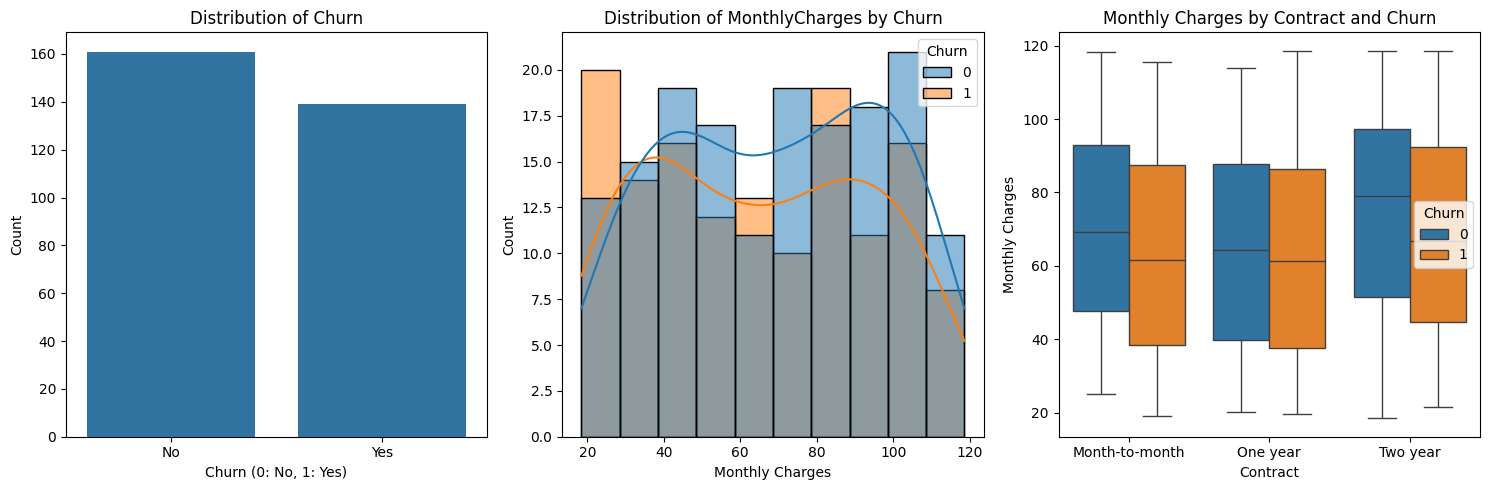

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability
plt.figure(figsize=(15, 5))

# 1. Bar plot of Churn distribution
plt.subplot(1, 3, 1)
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])

# 2. Histogram of MonthlyCharges by Churn
plt.subplot(1, 3, 2)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, common_norm=False)
plt.title('Distribution of MonthlyCharges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')

# 3. Box plot of Contract by Churn
plt.subplot(1, 3, 3)
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title('Monthly Charges by Contract and Churn')
plt.xlabel('Contract')
plt.ylabel('Monthly Charges')
plt.xticks(ticks=[0, 1, 2], labels=['Month-to-month', 'One year', 'Two year'])


plt.tight_layout()
plt.show()

## Visualize model performance

### Subtask:
Generate plots to visualize the performance of the trained model, such as a confusion matrix heatmap or an ROC curve.


**Reasoning**:
Generate a confusion matrix heatmap and an ROC curve plot to visualize the model's performance.



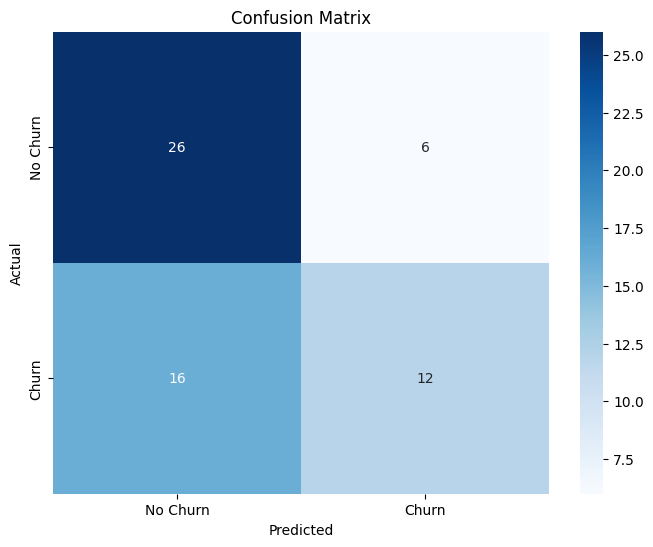

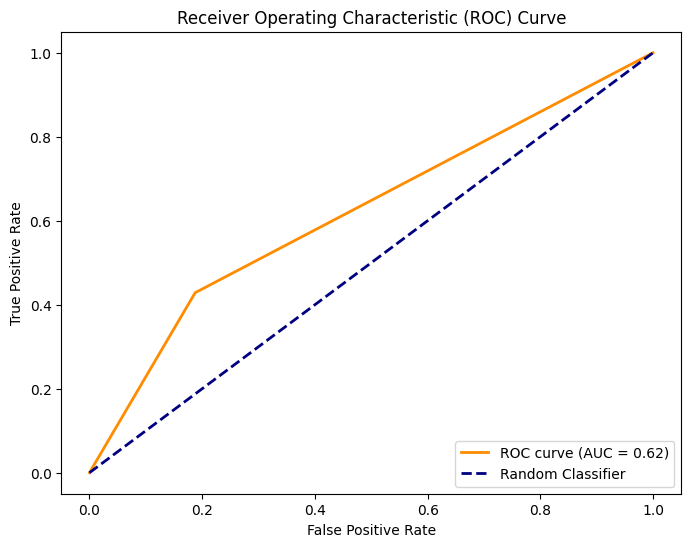

In [ ]:
from sklearn.metrics import roc_curve, auc

# Create Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The dataset shows a significant imbalance in the distribution of churn, with fewer customers who churned compared to those who did not.
*   Customers who churned tend to have higher monthly charges.
*   Customers with month-to-month contracts have higher monthly charges and are more likely to churn compared to those with one-year or two-year contracts.
*   The confusion matrix indicates the number of correct and incorrect predictions made by the model.
*   The ROC curve and AUC score provide a measure of the model's ability to distinguish between churned and non-churned customers.

### Insights or Next Steps

*   The imbalance in the churn distribution suggests the need for handling techniques such as oversampling or undersampling to potentially improve model performance.
*   Further analysis could explore feature importance to identify which variables are most influential in predicting churn.
